<a href="https://colab.research.google.com/github/Atanga-Theresa/Internship/blob/main/Titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Titanic Dataset: Exploratory Data Analysis and Cleaning

This notebook performs an in-depth exploratory data analysis (EDA) and cleaning of the Titanic dataset. The primary goal is to understand the various factors that influenced passenger survival during the disaster.

Key steps covered:

1.  Data Loading and Initial Inspection: Importing the dataset and examining its structure, data types, and initial summary statistics.
2.  Data Cleaning: Handling missing values in `Age`, `Cabin`, and `Embarked` columns, and correcting data types for better analysis.
3.  Exploratory Data Analysis (EDA): Visualizing distributions of key features and performing univariate analysis.
4.  Bivariate Analysis: Investigating relationships between various features and the `Survived` target variable.
5.  Correlation Analysis: Generating a correlation matrix to understand the linear relationships between numerical features.

These steps aim to uncover insights into passenger demographics, class, family size, and their impact on survival outcomes.

In [ ]:
#import all relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

In [ ]:
#import dataset as a dataframe (Titanic) using pandas
Titanic = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
#Displaying the first 10 rows
Titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
#3 checking the dataset structure
Titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#4 identifying - Number of rows and columns
Titanic.shape

(891, 12)

In [ ]:
# identifying- Data types of each column
Titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [ ]:
# identifying - Missing values
# Titanic.isnull()
Titanic.isnull().sum() #-to count the number of missing values in each column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# identifying- Duplicate records
#Titanic.duplicated()
Titanic.duplicated().sum() #to count duplicates

np.int64(0)

Summary on structure and quality of dataset

The Titanic dataset consists of 891 passenger records(rows) across 12 distinct columns. The overall quality of the dataset is moderate due to specific dimentional imbalances. Though the dataset is 100% unique(No duplicate rows found),has all features conforming structurally to their intended data types(Valid) and consistently free from internal contradictions,it's completeness is 91.90% since 866 cells are missing. This introduces a quality vulnerability as the missing cells are concentrated in just two columns,Cabin(77.1%) and Age(19.9%). This may require some progrmmatic imputation or feature drops before reliably using the data for analysis/modeling.

Data Cleaning

In [ ]:
# Identifying columns with missing values
Titanic.isnull().sum() # Age,Cabin and Embarked have missing Values(177,687 and 2 reapectively)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Handling Missing Values

In [ ]:
#In order not to lose information that may be valuable,a new column named "Has_Cabin" is created,indicating whether or not a passenger had their cabin information records available.
Titanic["Has_Cabin"] = Titanic["Cabin"].notnull().astype(int)

In [ ]:
#Dropping the Cabin column from the dataframe
Titanic.drop(columns=["Cabin"], inplace=True)

In [ ]:
#For age column,group age by passenger class is some-what related to age, group the age based on the passenger class(Pclass) and then fill the missing age values with the median age for each pclass group instead of directly filling with the median age of the whole Age column.
Titanic["Age"] = Titanic.groupby("Pclass")["Age"].transform(lambda x: x.fillna(x.median()))

In [ ]:
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1


In [ ]:
#Since the Embarked column has only two missing values it is appropriate to assume that the possibly would be the same vaues as the frequently occuring vone. Thus filling with the mode
Mode = Titanic["Embarked"].mode()[0]
print(f"The mode is: {Mode}")

The mode is: S


In [ ]:
# Filling the 2 null cells with the mode/frequently occuring value
Titanic["Embarked"] = Titanic["Embarked"].fillna( Titanic["Embarked"].mode()[0])

In [ ]:
# By way of verifying
Titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

CORRECTING DATA TYPES

In [ ]:
#checking whether data types are appropriate for each column
Titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Has_Cabin        int64
dtype: object

In [ ]:
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1


In [ ]:
# Changing Pclass to ordered category since the column values as the ticket classes have a natural rank and clear hierarchy
Class_order = CategoricalDtype(categories = [3, 2, 1], ordered=True)
Titanic["Pclass"] = Titanic["Pclass"].astype(Class_order)

In [ ]:
#Changing sex to categories since sex is a natural grouping
Titanic["Sex"] = Titanic["Sex"].astype("category")

In [ ]:
#changing data type for Embarked column into categories
Titanic["Embarked"] = Titanic["Embarked"].astype("category")

In [ ]:
#changing PassengerId to string to avoid accidental calculations
Titanic["PassengerId"] = Titanic["PassengerId"].astype(str)

In [ ]:
# Confirming data types
print(Titanic.dtypes)

PassengerId      object
Survived          int64
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
Has_Cabin         int64
dtype: object


In [ ]:
#saving cleaned dataset as csv
#Titanic.to_csv("C:\\Users\\windows 10\\Desktop\\Analyst Lab Africa Internship\\Cleaned_Titanic.csv", index=False)

EXPLORATORY DATA ANALYSIS(EDA)

In [ ]:
# Summary statistics only numeric columns
Titanic.describe()

,Survived,Age,SibSp,Parch,Fare,Has_Cabin
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,29.066409,0.523008,0.381594,32.204208,0.228956
std,0.486592,13.244532,1.102743,0.806057,49.693429,0.420397
min,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,26.000000,0.000000,0.000000,14.454200,0.000000
75%,1.000000,37.000000,1.000000,0.000000,31.000000,0.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [ ]:
# Summary statistics all numeric columns
# Titanic.describe(include="all")
Titanic.describe(include=["category","object"]) #for non numeric columns only

,PassengerId,Pclass,Name,Sex,Ticket,Embarked
count,891,891,891,891,891,891
unique,891,3,891,2,681,3
top,1,3,"Braund, Mr. Owen Harris",male,347082,S
freq,1,491,1,577,7,646


PLOTS

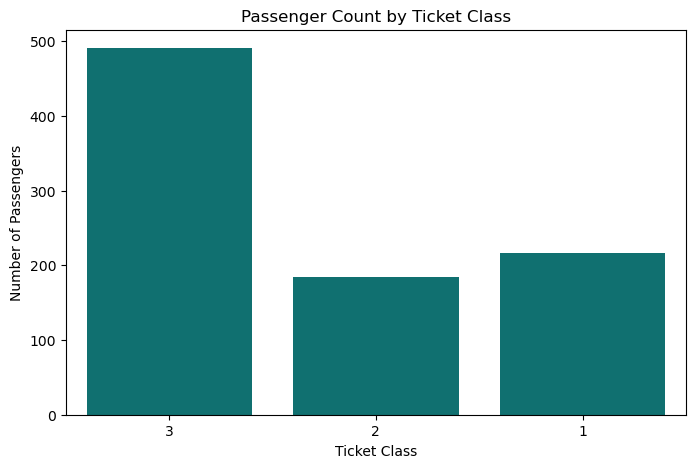

In [ ]:
# plot one-To understand the distribution of passengers across the ticket class
plt.figure(figsize=(8,5))
sns.countplot(data=Titanic, x="Pclass", color="teal")
plt.title("Passenger Count by Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Number of Passengers")
plt.show()

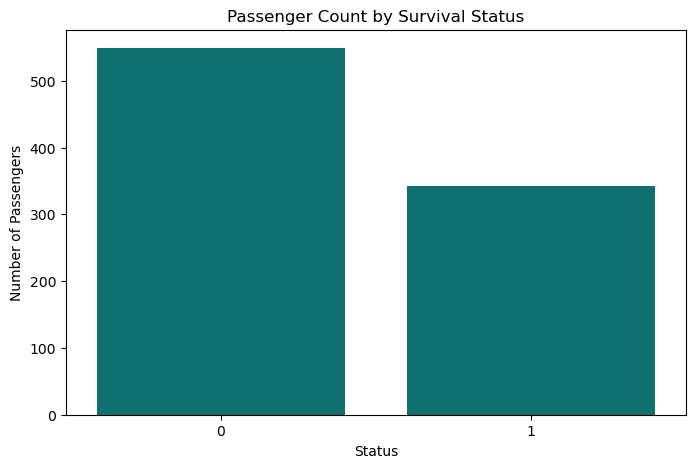

In [ ]:
# plot two- Passenger count by survival status(whether they survived or not)
plt.figure(figsize=(8,5))
sns.countplot(data=Titanic, x="Survived", color="teal")
plt.title("Passenger Count by Survival Status")
plt.xlabel("Status")
plt.ylabel("Number of Passengers")
plt.show()

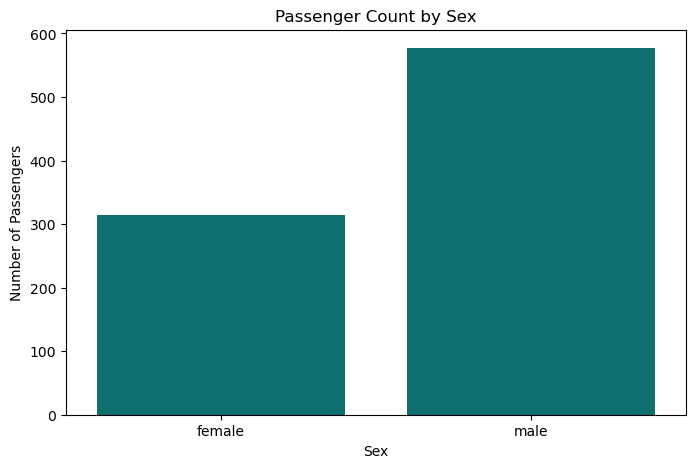

In [ ]:
# plot three- Passenger count by sex(How many passengers were male or female)
plt.figure(figsize=(8,5))
sns.countplot(data=Titanic, x="Sex", color="teal")
plt.title("Passenger Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.show()

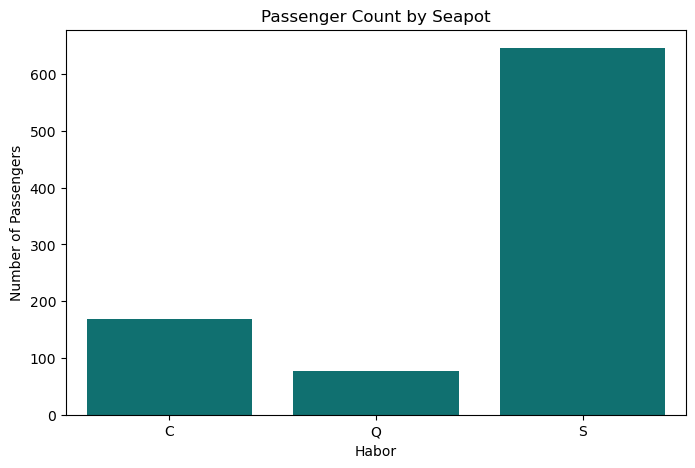

In [ ]:
# plot four-Passenger count by where the seaport/habor boarded the ship from
plt.figure(figsize=(8,5))
sns.countplot(data=Titanic, x="Embarked", color="teal")
plt.title("Passenger Count by Seapot")
plt.xlabel("Habor")
plt.ylabel("Number of Passengers")
plt.show()

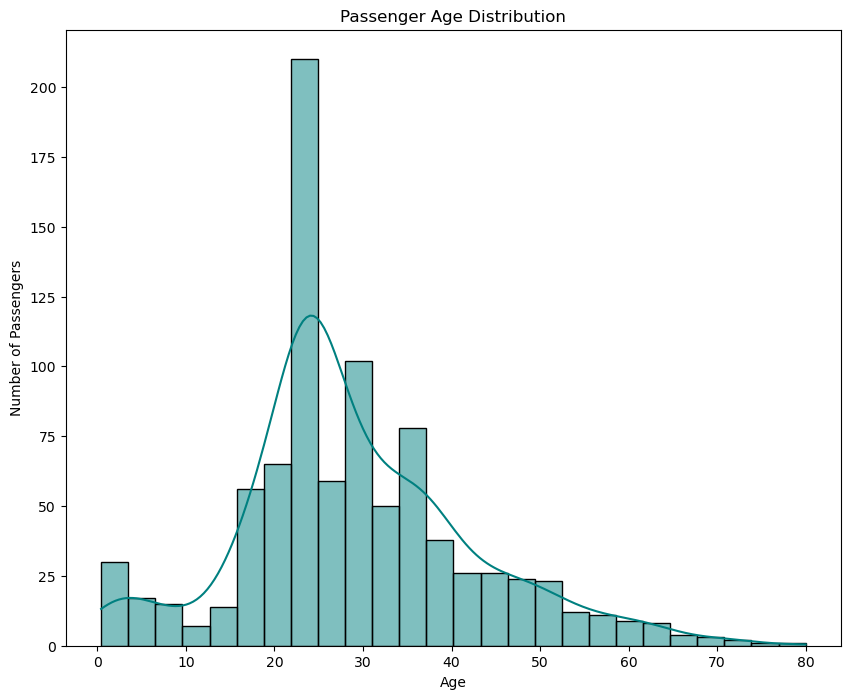

In [ ]:
#Plot five-Age distribution of passengers. For Age use histograms(continuos numerical values)
plt.figure(figsize=(10,8))
sns.histplot(data=Titanic, x="Age", color="teal",kde=True)
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

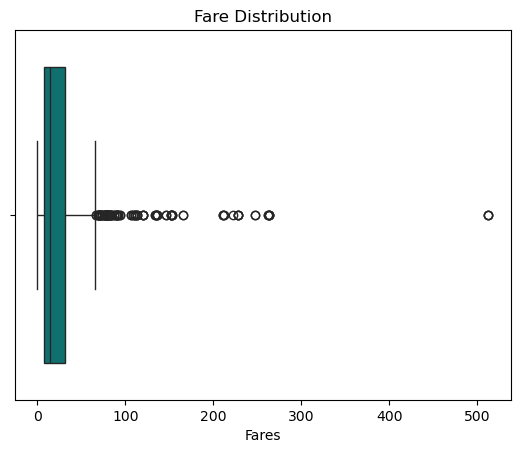

In [ ]:
# plot six-Fare distribution
sns.boxplot(data=Titanic, x="Fare", color="teal")
plt.title("Fare Distribution")
plt.xlabel("Fares")
plt.show()

Inferences from summary statistics

• Which features have the highest variation?
Ans: Fare has the highest variation among the features since it has the highest standard deviation(49.69) followed by age(13.24)

• Are there any outliers?
Ans: The statistical summary shows that 75% of the passengers spent 31.0 or less on fare whilst the maximum amount of fare is 512.39, this shows that there are outliers which is further confirmed by the long line of individual dots on the far right of the boxplot.

• Which categories occur most frequently?
Ans: S category in the Embarked column is the frequently occuring category(frequency=646). Male is the frequently occuring in sex(frequency=577) and 3rd class for Pclass(frequency=491)


In [ ]:
# Bivariate Analysis-Analyzing relationships between variables.


In [ ]:
Titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Has_Cabin'],
      dtype='object')

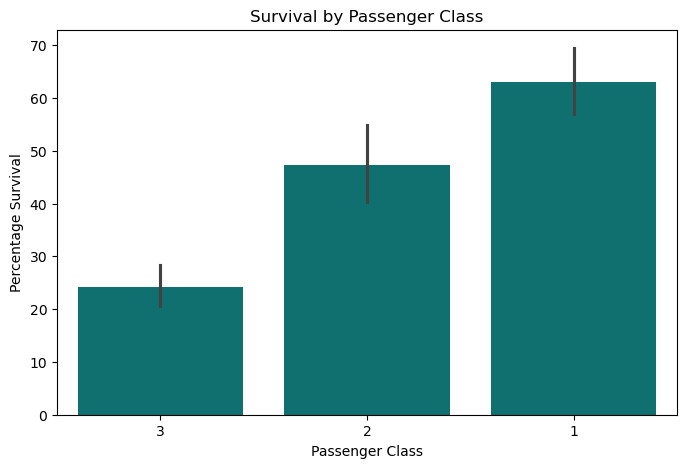

In [ ]:
# plot one-survival rate by Passenger class
plt.figure(figsize=(8,5))
sns.barplot(data=Titanic, x="Pclass", y=Titanic["Survived"] * 100, color="teal") #multiplied by 100 to conert to percentages for better understanding)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Percentage Survival")
plt.show()

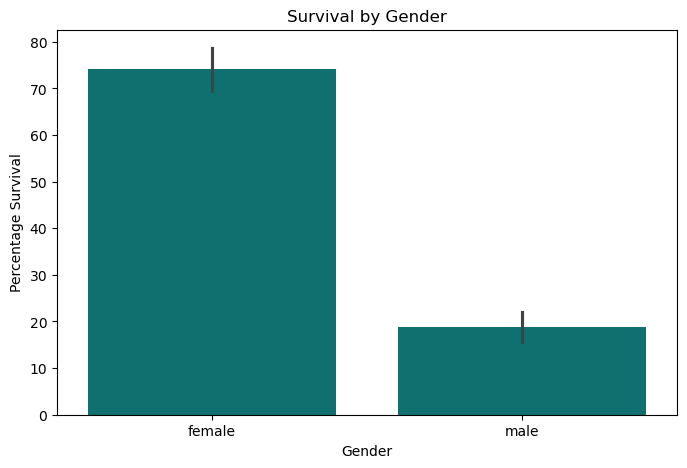

In [ ]:
# plot three-Sex vs Survived
plt.figure(figsize=(8,5))
sns.barplot(data=Titanic, x="Sex", y=Titanic["Survived"] * 100, color="teal")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage Survival")
plt.show()

#Reminder to always group age before creating barplots/charts where necessary especially for multivariate analysis
fig, axes =plt.subplots(1,2, figsize=(16,6))
sns.barplot(data=Titanic, x="Age", y=Titanic["Survived"] * 100, color="teal", ax=axes[0])
sns.barplot(data=Titanic, x="Age_Group", y=Titanic["Survived"] * 100, color="teal", ax=axes[1])
axes[1].set_title("Survival by Passenger Age")
axes[1].set_xlabel("Passenger Age Group")
axes[1].set_ylabel("Percentage Survival")
plt.show()

In [ ]:
# Creating a new column(Age_Group) for better visualization
age_bins = [0, 12, 19, 59, 100] #Defining the cut-off points
age_labels = ["Child", "Teenager", "Adult", "Senior"]# Defining text labels
Titanic["Age_Group"] = pd.cut(Titanic["Age"], bins = age_bins, labels=age_labels)

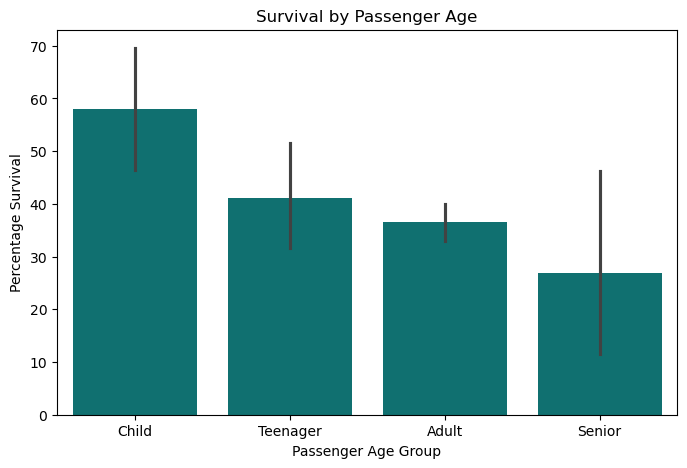

In [ ]:
# plot four-Survival by passenger age group
plt.figure(figsize=(8,5))
sns.barplot(data=Titanic, x="Age_Group", y=Titanic["Survived"] * 100, color="teal")
plt.title("Survival by Passenger Age")
plt.xlabel("Passenger Age Group")
plt.ylabel("Percentage Survival")
plt.show()

In [ ]:
Titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Has_Cabin', 'Age_Group'],
      dtype='object')

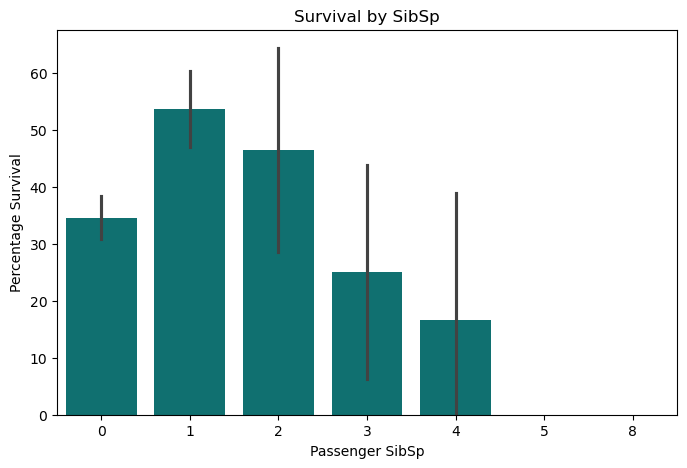

In [ ]:
# plot five-survival by number of siblings or spouses a passenger was travelling with
plt.figure(figsize=(8,5))
sns.barplot(data=Titanic, x="SibSp", y=Titanic["Survived"] * 100, color="teal")
plt.title("Survival by SibSp")
plt.xlabel("Passenger SibSp")
plt.ylabel("Percentage Survival")
plt.show()

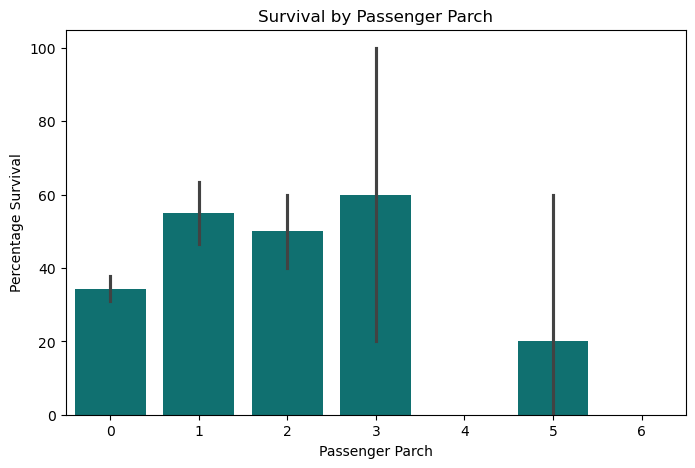

In [ ]:
# plot four-Survival vs number of parents/children passenger was on ship with
plt.figure(figsize=(8,5))
sns.barplot(data=Titanic, x="Parch", y=Titanic["Survived"] * 100, color="teal")
plt.title("Survival by Passenger Parch")
plt.xlabel("Passenger Parch")
plt.ylabel("Percentage Survival")
plt.show()

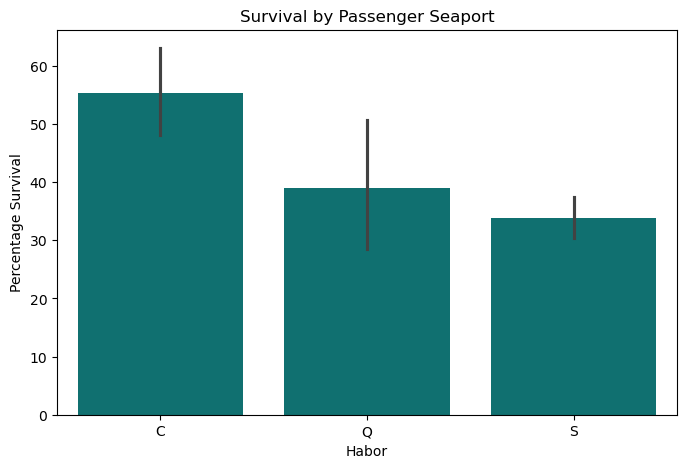

In [ ]:
#Percentage Survival vs Seaport passengers boarded from
plt.figure(figsize=(8,5))
sns.barplot(data=Titanic, x="Embarked", y=Titanic["Survived"] * 100, color="teal")
plt.title("Survival by Passenger Seaport")
plt.xlabel("Habor")
plt.ylabel("Percentage Survival")
plt.show()

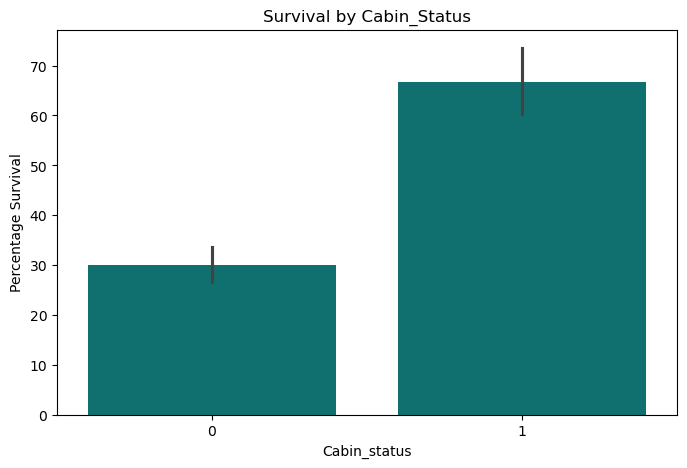

In [ ]:
# Survival vs whether or not cabin infomation is present
plt.figure(figsize=(8,5))
sns.barplot(data=Titanic, x="Has_Cabin", y=Titanic["Survived"] * 100, color="teal")
plt.title("Survival by Cabin_Status")
plt.xlabel("Cabin_status")
plt.ylabel("Percentage Survival")
plt.show()

In [ ]:
# Correlation matrix
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Teenager
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0,Adult
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,Adult


In [ ]:
# Calculating the correlation matrix
numeric_cols = Titanic.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()

# Displaying correlation_matrix
correlation_matrix

,Survived,Age,SibSp,Parch,Fare,Has_Cabin
Survived,1.000000,-0.047255,-0.035322,0.081629,0.257307,0.316912
Age,-0.047255,1.000000,-0.243526,-0.171095,0.123784,0.276032
SibSp,-0.035322,-0.243526,1.000000,0.414838,0.159651,-0.040460
Parch,0.081629,-0.171095,0.414838,1.000000,0.216225,0.036987
Fare,0.257307,0.123784,0.159651,0.216225,1.000000,0.482075
Has_Cabin,0.316912,0.276032,-0.040460,0.036987,0.482075,1.000000


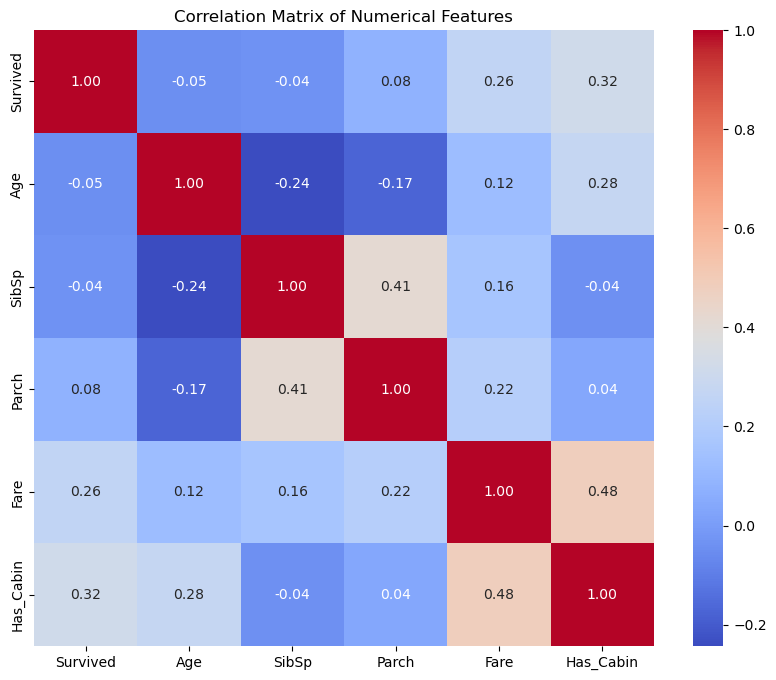

In [ ]:
#Generating the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Highly Correlated Variables with Survived:
    
Has_Cabin (0.32): There is a moderate positive correlation between having cabin information and survival. This suggests that passengers with recorded cabins (often indicating higher class) had a significantly better chance of survival.

Fare (0.26): Fare also shows a moderate positive correlation with Survived. This aligns with the Has_Cabin correlation, as higher fares often correspond to higher classes and better access to lifeboats.

Parch (0.08): A weak positive correlation exists between the number of parents/children and survival. This could imply that passengers traveling with young children or elderly parents might have received preferential treatment, though the correlation is not very strong.
Age (-0.05) and SibSp (-0.04) have very weak (almost negligible) correlations with Survived, suggesting a linear relationship between these features and survival is not strong. However, this does not rule out non-linear relationships or interactions with other features.

Features that may be important for future machine learning models:

Considering the direct correlations with Survived and potential relationships among features, the following are likely important for modeling:

Has_Cabin: This feature shows the strongest linear relationship with survival among the numerical features.

Fare: As Fare is also moderately correlated with Survived and strongly correlated with Has_Cabin (0.48), it's a strong proxy for socio-economic status and potentially location on the ship, both of which were critical for survival.
Age: Despite its weak direct linear correlation, Age is a crucial feature in survival prediction tasks.

Sex (implicitly important): Although not a numerical column in this correlation matrix, Sex is a known dominant factor in Titanic survival (women and children first policy). Its impact should definitely be considered in any machine learning model.

Pclass (implicitly important): Similar to Sex, Pclass is a categorical variable that was converted to an ordered category. It is highly correlated with Fare and Has_Cabin and is a primary driver of survival, so it's a critical feature.

Potential Multicollinearity:
Fare and Has_Cabin (0.48): These two features are moderately correlated. While not extremely high, it indicates that they capture similar aspects (wealth/class). A model might still benefit from both, but it's good to be aware of their shared information. Depending on the model, one might be preferred over the other or they could be combined into a new feature.

SibSp and Parch (0.41): These features also show a moderate positive correlation, which is expected as they both represent family size. For modeling, it might be beneficial to combine them into a single FamilySize feature to avoid redundancy and potentially capture the overall family impact more effectively.

In summary, Has_Cabin, Fare, Age (and its categorical representation), Sex, and Pclass are critical features to consider for predicting survival. The correlations provide a good starting point for feature selection and engineering in a machine learning pipeline.